In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
import joblib

In [2]:
#Euclidean Distance
pointA = np.array([2, 4, 6])
pointB = np.array([5, 1, 9])
euclidean_dist = distance.euclidean(pointA, pointB)
print("Euclidean Distance:", euclidean_dist)
similarity_euclidean = 1 / (1 + euclidean_dist)
print("Euclidean Similarity:", similarity_euclidean)

Euclidean Distance: 5.196152422706632
Euclidean Similarity: 0.16139047779640892


In [3]:
# Manhattan Distance
pointA = np.array([2, 4, 6])
pointB = np.array([5, 1, 9])
manhattan_dist = distance.cityblock(pointA, pointB)
print("Manhattan Distance:", manhattan_dist)
similarity_manhattan = 1 / (1 + manhattan_dist)
print("Manhattan Similarity:", similarity_manhattan)

Manhattan Distance: 9
Manhattan Similarity: 0.1


In [4]:
# Minkowski Distance (p=3)
pointA = np.array([2, 4, 6])
pointB = np.array([5, 1, 9])
minkowski_dist = distance.minkowski(pointA, pointB, p=3)
print("Minkowski Distance (p=3):", minkowski_dist)
similarity_minkowski = 1 / (1 + minkowski_dist)
print("Minkowski Similarity:", similarity_minkowski)

Minkowski Distance (p=3): 4.3267487109222245
Minkowski Similarity: 0.1877317767871331


In [6]:
df = pd.DataFrame({
    'X': [10, 20, 30, 40, 50],
    'Y': [12, 24, 33, 45, 60]
})
corr_matrix = df.corr(method='pearson')
print("Pearson Correlation Matrix:")
corr_matrix

Pearson Correlation Matrix:


,X,Y
X,1.000000,0.996403
Y,0.996403,1.000000


In [8]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/Iris.csv")
df.corr(method='pearson', numeric_only=True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.716676,-0.397729,0.882747,0.899759
SepalLengthCm,0.716676,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.882747,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.899759,0.817954,-0.356544,0.962757,1.000000


In [10]:
df = pd.DataFrame({
    'X': [10, 20, 30, 40, 50],
    'Y': [12, 18, 33, 47, 55]
})
corr_value, p_value = spearmanr(df['X'], df['Y'])
print("Spearman Correlation:", corr_value)
print("P-value:", p_value)

Spearman Correlation: 0.9999999999999999
P-value: 1.4042654220543672e-24


In [13]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/Iris.csv")
df.corr(method='spearman', numeric_only=True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.734054,-0.411539,0.868498,0.879045
SepalLengthCm,0.734054,1.000000,-0.159457,0.881386,0.834421
SepalWidthCm,-0.411539,-0.159457,1.000000,-0.303421,-0.277511
PetalLengthCm,0.868498,0.881386,-0.303421,1.000000,0.936003
PetalWidthCm,0.879045,0.834421,-0.277511,0.936003,1.000000


In [14]:
def hamming_distance(str1, str2):
    if len(str1) != len(str2):
        raise ValueError("Strings must be of equal length")
    return sum(ch1 != ch2 for ch1, ch2 in zip(str1, str2))
s1 = "karolin"
s2 = "kathrin"
dist = hamming_distance(s1, s2)
print("Hamming Distance:", dist)

Hamming Distance: 3


In [15]:
def jaccard_index(str1, str2):
    set1 = set(str1.split())
    set2 = set(str2.split())
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    return len(intersection) / len(union)
s1 = "data science is fun"
s2 = "science makes data useful"
print("Jaccard Index:", jaccard_index(s1, s2))

Jaccard Index: 0.3333333333333333


In [17]:
s1 = "data science is fun"
s2 = "science makes data useful"
vectorizer = CountVectorizer().fit([s1, s2])
vectors = vectorizer.transform([s1, s2])
cos_sim = cosine_similarity(vectors[0], vectors[1])[0][0]
print("Cosine Similarity:", cos_sim)

Cosine Similarity: 0.5


In [18]:
def lcs_length(X, Y):
    m = len(X)
    n = len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if X[i] == Y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(
                    dp[i][j + 1],
                    dp[i + 1][j]
                )
    return dp[m][n]
seq1 = "ABCDEF"
seq2 = "AEBDF"
length = lcs_length(seq1, seq2)
print("Longest Common Subsequence Length:", length)

Longest Common Subsequence Length: 4


In [19]:
# Define the problem

objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes


In [26]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/titanic.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
df = pd.read_csv("/content/drive/MyDrive/Datasets(Data Science)/titanic.csv")
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)
df.drop_duplicates(inplace=True)
df = pd.get_dummies(
    df,
    columns=['Sex', 'Pclass', 'Embarked'],
    drop_first=True
)
df['family_size'] = df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,family_size
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True,False,True,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False,False,False,1
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True,False,True,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,False,False,True,1
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True,False,True,0


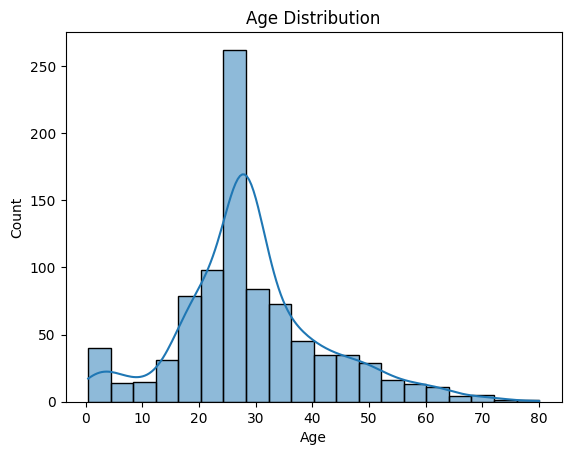

In [34]:
sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)
plt.title("Age Distribution")
plt.show()

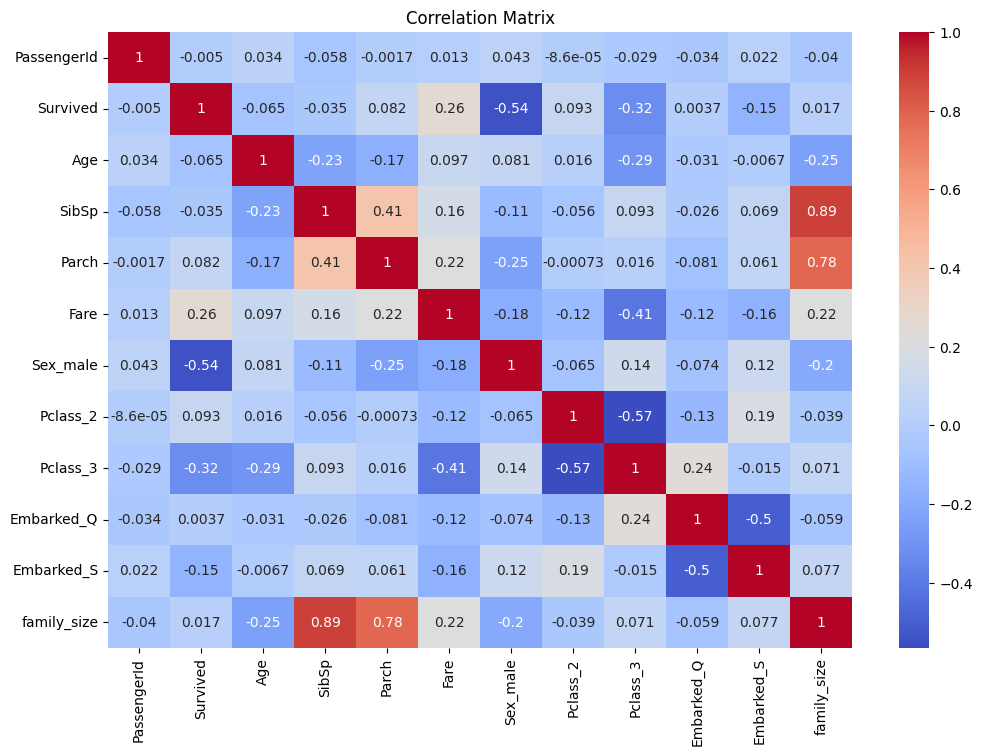

In [36]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [40]:
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'])
Y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)
model = LogisticRegression(
    max_iter=1000
)
model.fit(X_train, y_train)
print("Model Training Completed")

Model Training Completed


In [42]:
y_pred = model.predict(X_test)
print("Accuracy:",
      accuracy_score(y_test, y_pred))
print("Precision:",
      precision_score(y_test, y_pred))
print("Recall:",
      recall_score(y_test, y_pred))
print(
    "Confusion Matrix:\n",
    confusion_matrix(y_test, y_pred)
)

Accuracy: 0.8044692737430168
Precision: 0.7910447761194029
Recall: 0.7162162162162162
Confusion Matrix:
 [[91 14]
 [21 53]]


In [44]:
joblib.dump(
    model,
    "titanic_model.pkl"
)
print("Model Saved Successfully")

Model Saved Successfully


In [45]:
df

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,family_size
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True,False,True,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False,False,False,1
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True,False,True,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,False,False,True,1
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,True,True,False,False,True,0
887,888,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,False,False,False,False,True,0
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,NaN,False,False,True,False,True,3
889,890,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,True,False,False,False,False,0
